### Adding collisions to the simulation

This notebook is a follow-up to the one titled Gravity_simulation_theory.ipynb. In this one, we make our simulation more complex by adding collisions, that can be both elastic and inelastic. This way we can also get rid of the 'minimal distance' check, that prevents infinities when objects get too close to each other, as they will collide before the forces get too large now instead.

Below, some of the code to set up the simpler simulation is copied, but with initial conditions that will cause collisions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

G = 1
dt = 1e-4  # timestep
N_steps = 10000
N_objects = 2

# Make an array with the mass of each object
masses = np.array([0.1, 0.1])

# Make an array 'positions' to mark the positions of the objects
# Here positions[i] are the positions of all objects at timestep i,
# positions[i][j] is the position of object j at timestep i,
# positions[i][j][k] is the k-coordinate of object j at timestep i.
positions = np.zeros(shape=[N_steps, N_objects, 3])  # 3 for x, y, z coordinates

# Choose initial positions
positions[0][0] = np.array([1,0,0])
positions[0][1] = np.array([-1,0,0])

# Make an array 'velocities' to mark the velocities of the objects
# with the same structure as positions
velocities = np.zeros(shape=[N_steps, N_objects, 3])

# Choose initial velocities
velocities[0][0] = np.array([-1,1,0])
velocities[0][1] = np.array([1,1,0])

def gravity_force(m_i, m_j, r_i, r_j):
    """
    Calculate the gravitational force exerted on object i by object j.
    Parameters:
        - m_i (float): Mass of object i
        - m_j (float): Mass of object j
        - r_i (np.array): Position vector of object i
        - r_j (np.array): Position vector of object j
    """
    r_ij = r_i - r_j
    distance = np.linalg.norm(r_ij)
    unit_r_ij = r_ij / distance
    return -G * m_i * m_j / distance**2 * unit_r_ij

def next_velocity(current_velocity, next_acceleration, current_acceleration):
    """
    Find the velocity at the next timestep using the Verlet integration method.
    Parameters:
        - current_velocity (np.array): Velocity at the current timestep
        - next_acceleration (np.array): Acceleration at the next timestep
        - current_acceleration (np.array): Acceleration at the current timestep
    """
    return current_velocity + 0.5 * dt * (next_acceleration + current_acceleration)

# Note that the next_position function will be altered, and is defined again below.

To start, we then want to assign a radius $R$ to every object. A collision occurs when the distance between two objects is smaller or equal to the sum of both objects' radii: $|\vec{r}_i - \vec{r}_j| \leq R_i + R_j$.

In [2]:
radii = np.array([0.5, 0.5])

Now we begin by considering the collisions themselves. This is generally quite a complicated problem: objects can collide in many different ways, coming at each other with varying velocities in all directions, following trajectories at different angles. It is no fun to have to calculate how velocities change in collisions where the line connecting the centres of the objects is not neatly along one axis and where they both come in at some velocity. Luckily for us, it is possible to reduce every possible collision to the very simplest case of one object hitting another stationary object along, say, the $x$-axis.
To achieve this, we need to perform two kinds of transformations. The first is the Galilean transformation, the second a rotation.

We first look at the Galilean transformation. This simply allows one to switch between reference frames that are moving at different constant velocities. In other words, instead of standing on the station and watching the train move past, we can also imagine moving along with the train at the same speed.
In general, if we have an object with velocity $\vec{v}_i$ that we observe while moving at some speed ourselves (which could just be 0), changing our velocity by $\vec{u}$ means that we will then observe this object to have a velocity of $\vec{v}_i - \vec{u}$, so we subtract our velocity. We then thus observe the object in a reference frame moving with relative velocity $\vec{u}$. If we want to return to our original reference frame, we simply add $\vec{u}$ to the object's velocity again.
This becomes useful for collisions between two objects $i$ and $j$ when we take this velocity of our new reference frame to be $\vec{v}_j$, that is, when we move along with the second object. This way, it appears to be stationary, while the first object now moves with a velocity of $\vec{v}_i - \vec{v}_j$. Then we let the collision happen, which has become much simpler physically because one object is stationary. Afterwards, we can transform back by adding $\vec{v}_j$ to whatever velocities both objects ended up with after the collision (which we'll get back to later), to return to our original reference frame.

In [3]:
def galilean_transform(target_velocity, frame_velocity):
    """
    Perform a Galilean transformation.
    Parameters:
        - target_velocity (np.array): Velocity of the object that is to be transformed
        - frame_velocity (np.array): Velocity of the frame you want to transform to
    """
    return target_velocity - frame_velocity

Before even letting the collision happen, we will however apply the second transformation of the rotation, to make the physics even simpler. This is because even when one object is stationary, the way objects come into contact can still make things complicated. Imagine e.g. that the moving object moves diagonally, but ends up hitting the second one perfectly vertically, in the sense that they are momentarily side by side horizontally. All forces are then in this horizontal direction, so we expect the hit object to start moving in that direction only, where the momentum transfer happens. Now if this direction, that is generally on the line passing through the centres of both objects, is not aligned with an axis, we have to work with the three components of the velocity which can be difficult. So to make things easier, we rotate our frame of reference such that we align the $x$-axis with that line between the centres of the objects. In this new coordinate system, we can regard the velocity as having one component parallel to the line between centres, and the other two perpendicular to this line. Then when the collision happens, only the parallel component is relevant, and the other two remain unchanged, so that we don't need to think about them. After the collision, we can rotate back to our original frame again. Note that we need to define three angles to be able to rotate our vector in a 3D-space, one for each axis you can rotate around. We'll denote these by $\alpha$, $\beta$ and $\gamma$ for the $x$-, $y$- and $z$-axis, respectively. Writing the distances between the coordinates of the two colliding objects as $\Delta x = x_i - x_j$ etc., these angles are given by
\begin{equation}
\nonumber
    \tan{\alpha} = \frac{\Delta z}{\Delta y},
\end{equation}

\begin{equation}
\nonumber
    \tan{\beta} = \frac{\Delta x}{\Delta z},
\end{equation}

\begin{equation}
\nonumber
    \tan{\gamma} = \frac{\Delta y}{\Delta x}.
\end{equation}

To apply the rotation to a vector, we multiply it with a rotation matrix $R$. We thus have three of these, for each axis:
\begin{equation}
\nonumber
    R_x(\alpha) = 
    \begin{pmatrix}
    1 & 0 & 0 \\
    0 & \cos{\alpha} & -\sin{\alpha} \\
    0 & \sin{\alpha} & \cos{\alpha}
    \end{pmatrix},
\end{equation}

\begin{equation}
\nonumber
    R_y(\beta) = 
    \begin{pmatrix}
    \cos{\beta} & 0 & \sin{\beta} \\
    0 & 1 & 0 \\
    -\sin{\beta} & 0 & \cos{\beta}
    \end{pmatrix},
\end{equation}

\begin{equation}
\nonumber
    R_z(\gamma) = 
    \begin{pmatrix}
    \cos{\gamma} & -\sin{\gamma} & 0 \\
    \sin{\gamma} & \cos{\gamma} & 0 \\
    0 & 0 & 1
    \end{pmatrix}.
\end{equation}

We can then rotate a vector by multiplying it by these matrices, like $\vec{a}' = R_x R_y R_z \vec{a}$. The inverse rotation can be achieved using the same matrices, but using angle $-\theta$ instead of $\theta$ and by reversing the order of the matrices, since $\vec{a} = R_z^{-1} R_y^{-1} R_x^{-1} \vec{a}'$ and $R(\theta)^{-1} = R(-\theta)$.

In [4]:
def get_rotation_angles(position_i, position_j):
    """
    Calculate the rotation angles around the axes to align with 
    the line between the centres of the objects i and j.
    Parameters:
        - position_i (np.array): Position vector of object i
        - position_j (np.array): Position vector of object j
    Returns:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
    """
    difference = position_i - position_j  # (delta_x, delta_y, delta_z)
    # Using arctan2 ensures the right quadrant sign
    alpha = np.arctan2(difference[2], difference[1])
    beta = np.arctan2(difference[0], difference[2])
    gamma = np.arctan2(difference[1], difference[0])
    return alpha, beta, gamma

def rotation(alpha, beta, gamma, target_vector):
    """
    Perform a rotation around the x, y and z axis.
    Parameters:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
        - target_vector (np.array): Vector you want to rotate
    """
    rotation_matrix_x = np.array([
        [1, 0, 0],
        [0, np.cos(alpha), -np.sin(alpha)],
        [0, np.sin(alpha), np.cos(alpha)]
    ])
    rotation_matrix_y = np.array([
        [np.cos(beta), 0, np.sin(beta)],
        [0, 1, 0],
        [-np.sin(beta), 0, np.cos(beta)]
    ])
    rotation_matrix_z = np.array([
        [np.cos(gamma), -np.sin(gamma), 0],
        [np.sin(gamma), np.cos(gamma), 0],
        [0, 0, 1]
    ])
    combined_rotation = rotation_matrix_x @ rotation_matrix_y @ rotation_matrix_z  # Note xyz
    return combined_rotation @ target_vector

def inverse_rotation(alpha, beta, gamma, target_vector):
    """
    Perform an inverse rotation around the x, y and z axis,
    compared to the function above. Note no minus sign on the
    angles is needed relative to above!
    Parameters:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
        - target_vector (np.array): Vector you want to rotate
    """
    rotation_matrix_x = np.array([
        [1, 0, 0],
        [0, np.cos(alpha), -np.sin(-alpha)],
        [0, np.sin(-alpha), np.cos(alpha)]
    ])
    rotation_matrix_y = np.array([
        [np.cos(beta), 0, np.sin(-beta)],
        [0, 1, 0],
        [-np.sin(-beta), 0, np.cos(beta)]
    ])
    rotation_matrix_z = np.array([
        [np.cos(gamma), -np.sin(-gamma), 0],
        [np.sin(-gamma), np.cos(gamma), 0],
        [0, 0, 1]
    ])
    combined_rotation = rotation_matrix_z @ rotation_matrix_y @ rotation_matrix_x  # Note zyx
    return combined_rotation @ target_vector

Thus any collision is turned into the simple one-dimensional case of a moving object hitting a stationary object. In the case of objects with equal masses, this simply transfers the velocity from the moving object to the stationary one, so that the first is now stationary while the second moves away with the same speed. For objects with different masses, we can combine momentum and energy conservation to find the velocities after the collision. Let $v_1$ be the velocity of the moving object before colliding, and $v_2=0$ that of the stationary object. (Note we don't need to write these as vectors, as these are just one-dimensional now.) After the collision, their velocities $v'_1$ and $v'_2$ are given by

\begin{equation}
\nonumber
    v'_1 = \frac{m_1 - m_2}{m_1 + m_2} v_1,
\end{equation}

\begin{equation}
\nonumber
    v'_2 = \frac{2m_1}{m_1 + m_2} v_1.
\end{equation}

We can summarize all this in a 5-step recipe:

1. Perform a Galilean transform such that one object is stationary
2. Perform a rotation to align the $x$-axis with a line through the centres of both objects
3. Calculate the new velocities after the collision
4. Perform the inverse rotation
5. Perform the inverse Galilean transform

However, we can add some more complexity to our simulation by also allowing for so-called inelastic collisions. The equations above only apply when a collision is perfectly elastic, meaning no kinetic energy is lost to e.g. heat. If we do allow for energy to leak away, we call it an inelastic collision. This is parametrized using the coefficient of restitution $e$ (see e.g. https://en.wikipedia.org/wiki/Inelastic_collision), which is defined as the ratio of the difference in velocity before and after the collision:
\begin{equation}
\nonumber
    e = \frac{|v'_1 - v'_2|}{|v_1 - v_2|}.
\end{equation}

The value of $e$ is between 0 and 1; for $e=1$ we have a perfectly elastic collision, so that the kinetic energy is conserved, and for $e=0$ a perfectly inelastic collision, with the most energy loss, where the objects end up 'sticking together' in the sense that they move at the same speed ($|v'_1 - v'_2|=0$). Now although energy leaks away so that we cannot use the same energy conservation criterium again, momentum is still conserved in inelastic collisions, so that combining this with the definition of $e$ gives us

\begin{equation}
\nonumber
    v'_1 = \frac{m_1 - e m_2}{m_1 + m_2} v_1,
\end{equation}

\begin{equation}
\nonumber
    v'_2 = \frac{m_1 + e m_1}{m_1 + m_2} v_1.
\end{equation}

Note that for $e=1$, these indeed reduce to the equations we got for perfectly elastic collisions, while for $e=0$, the objects end up with the same speed.

One thing to keep in mind is that we only want to apply this type of inelastic velocity transfer in the direction of which the collision happens; you can imagine that when e.g. objects collide on a horizontal line, any velocity they had in a vertical direction just remains unchanged still. Our method of rotating the axes makes sure that this is the case in the simulation, as we only change the speed in the direction of the line through the centres of both objects.

In [5]:
e = 0.5  # coefficient of restitution

def velocity_transfer_collision(m_i, m_j, velocity_before_i):
    """
    Calculate the velocity of object i and j after an (in)elastic
    collision, where i moves and j is stationary.
    Parameters:
        - m_i (float): Mass of object i
        - m_j (float): Mass of object j
        - velocity_before_i (np.array): Velocity of object i before the collision
    Returns:
        - velocity_after_i (np.array): Velocity of object i after the collision
        - velocity_after_j (np.array): Velocity of object j after the collision
    """
    velocity_after_i = (m_i - e * m_j) / (m_i + m_j) * velocity_before_i
    velocity_after_j = (1 + e) * m_i / (m_i + m_j) * velocity_before_i
    return velocity_after_i, velocity_after_j

On top of this, while testing I found that it is possible that after a collision, the objects have not moved far apart enough yet in the next timestep such that their distance is still smaller that the sum of their radii, causing the simulation to again run the collision calculation. This results in incorrect trajectories, since the collision logic is not supposed to be applied there. To prevent this, we add another check, to determine whether objects are actually moving towards each other.

In 1D, you can quickly figure out that this happens when either $x_1 < x_2$ and $v_1 > v_2$, or when the opposite is true, $x_1 > x_2$ and $v_1 < v_2$. In 3D, you can separately consider this condition for each axis, i.e. for each component of the position and velocity vector. If they hold for any of the axes, the objects move towards each other in at least one direction, meaning a collision should occur.

In [6]:
def objects_move_towards_each_other(position_i, position_j, velocity_i, velocity_j):
    """
    Determine if objects i and j are moving towards each other, so that a collision 
    can happen. This is the case if for any of the components of the position and 
    velocity vectors, the position component of i is smaller and the velocity 
    component of i is larger, or vice versa.
    Parameters:
        - position_i (np.array): Position vector of object i
        - position_j (np.array): Position vector of object j
        - velocity_i (np.array): Velocity vector of object i
        - velocity_j (np.array): Velocity vector of object j
    Returns:
        - bool: True if objects move towards each other
    """
    position_mask = position_i > position_j
    velocity_mask = velocity_i > velocity_j
    # We need position_i to be smaller and velocity_i larger or vice versa,
    # meaning these masks do not have the same value
    collisions = position_mask != velocity_mask
    # If any of these is True, there will be a collision
    return np.any(collisions)

Before we can then run the simulation, there is one more thing we need to deal with: in the Verlet algorithm, the positions we calculate are not actually affected by a change in velocity due to a collision, since those do not depend on velocity explicitly. The most straightforward way I could find to remedy this, is to change the way we calculate the positions, now using the so-called velocity Verlet algorithm. This uses the same equation to calculate the velocity, but for the position we now use

\begin{equation}
\nonumber
    \vec{r}_i (t+dt) = \vec{r}_i(t) + \vec{v}_i(t) dt + \frac{1}{2} \vec{a}_i (t) dt^2.
\end{equation}

It can be shown that this results in the same trajectories, and possesses the same order of error as the standard Verlet method. Additionally, we do not need to calculate the first positions separately anymore, as the next position now only depends on the current one, not also the previous. Note that the equation here is the same as we previously used for this first timestep only, the Euler integration; because we still calculate the velocity using the Verlet method, instead of Euler's $\vec{v}_i(t+dt) = \vec{v}_i(t) + \vec{a}_i(t) dt$, this position integration method is still accurate. (In retrospect, it may have been easier to do this from the start in the original script as well.)

In [7]:
def next_position(current_position, current_velocity, current_acceleration):
    """
    Find the position at the next timestep using the velocity Verlet integration method.
    Parameters:
        - current_position (np.array): Position at the current timestep
        - current_velocity (np.array): Velocity at the current timestep
        - current_acceleration (np.array): Acceleration at the current timestep
    """
    return current_position + current_velocity * dt + 0.5 * current_acceleration * dt**2

Now all of this can be implemented in the simulation. Every time we update the positions, we check if a collision happens, and if so, change the velocities of the involved objects accordingly.

In [8]:
# Also need to keep the previous acceleration for velocity
# Note we don't save these for all timesteps, only the previous one
previous_accelerations = np.zeros(shape=[N_objects, 3])

# Then also determine acceleration for step 0
for j in range(N_objects):
    force = np.zeros(3)  # to add up all forces on object j
    for k in range(N_objects):
        # Consider all other objects k, so without k==j
        if k != j:
            force += gravity_force(masses[j], masses[k], positions[0][j], positions[0][k])
    previous_accelerations[j] = force / masses[j]  # update these to contain step 0 accelerations

# Main simulation loop
for i in range(1, N_steps):  # 0 set by initial conditions
    for j in range(N_objects):
        # Update positions, with the already calculated previous acceleration
        positions[i][j] = next_position(positions[i-1][j], velocities[i-1][j], previous_accelerations[j])

    # Once all positions are updated, calculate new accelerations and update velocities
    for j in range(N_objects):
        force = np.zeros(3)  # to add up all forces on object j
        for k in range(N_objects):
            # Consider all other objects k, so without k==j
            if k != j:
                force += gravity_force(masses[j], masses[k], positions[i][j], positions[i][k])
        acceleration = force / masses[j]  # add to collision acceleration

        # So update velocities
        velocities[i][j] = next_velocity(velocities[i-1][j], acceleration, previous_accelerations[j])
        # And update the previous acceleration for the next loop
        previous_accelerations[j] = acceleration
    
    # Collisions
    for j in range(N_objects):
        position_j = positions[i][j]
        velocity_j = velocities[i][j]
        # Now only check for collisions between object pairs
        for k in range(j+1, N_objects):
            position_k = positions[i][k]
            velocity_k = velocities[i][k]
            # Check collision condition
            difference = position_j - position_k
            distance = np.linalg.norm(difference)
            if distance <= (radii[j] + radii[k]) and objects_move_towards_each_other(position_j, position_k, velocity_j, velocity_k):
                # 1 Galilean transform, with velocity_k as the frame velocity
                transformed_velocity = galilean_transform(velocity_j, velocity_k)

                # 2 Rotation
                alpha, beta, gamma = get_rotation_angles(position_j, position_k)
                rotated_transformed_velocity = rotation(alpha, beta, gamma, transformed_velocity)

                # 3 Velocity transfer
                velocity_after_j, velocity_after_k = velocity_transfer_collision(masses[j], masses[k], rotated_transformed_velocity)

                # 4 Inverse rotation
                velocity_after_j = inverse_rotation(alpha, beta, gamma, velocity_after_j)
                velocity_after_k = inverse_rotation(alpha, beta, gamma, velocity_after_k)

                # 5 Inverse Galilean transform
                velocity_after_j = galilean_transform(velocity_after_j, -velocity_k)
                velocity_after_k = galilean_transform(velocity_after_k, -velocity_k)

                # And finally assign
                velocities[i][j] = velocity_after_j
                velocities[i][k] = velocity_after_k

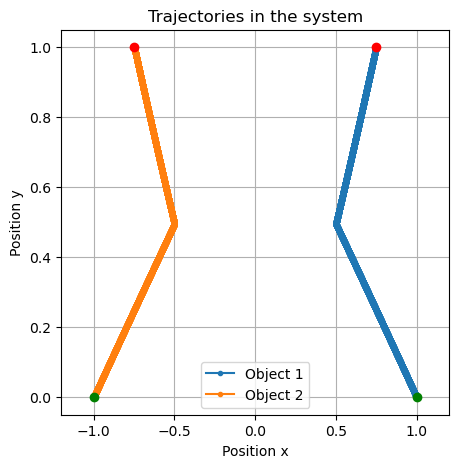

In [9]:
plt.figure(figsize=(5,5))
for i in range(N_objects):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Trajectories in the system')
plt.legend()
plt.xlim(-1.2, 1.2)
#plt.ylim(-0.2, 1.2)
plt.grid()
plt.show()

This indeed looks like a proper inelastic collision. The radius of 0.5 of both objects is clearly visible. The distance traveled in $y$ is the same before and after the collision, while the energy loss due to $e=0.5$ only lets the objects travel half as far in $x$ after the collision. This all lines up with our expectations.

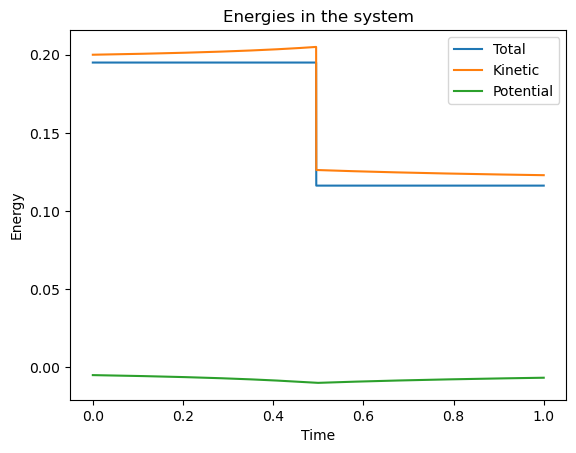

Energy difference:  -0.07875038556090828


In [10]:
times = np.arange(N_steps) * dt
# Get the kinetic energies from velocities
kinetic_per_particle = 0.5 * masses * np.sum(velocities**2, axis=2)
kinetic_total = np.sum(kinetic_per_particle, axis=1)

# Get the potential energies from positions
potential_total = np.zeros(shape=[N_steps])
for j in range(N_objects-1):  # don't need to consider the last object, is cancelled in next loop
    r_j = positions[:,j,:]
    for k in range(j+1, N_objects):  # start from the object after j
        r_k = positions[:,k,:]
        distance = np.linalg.norm(r_j - r_k, axis=1)  # distance between j and k at all timesteps
        
        potential_jk = -G * masses[j] * masses[k] / distance
        potential_total += potential_jk

energy = kinetic_total + potential_total

# Plot the different energies over time
plt.figure()
plt.plot(times, energy, label="Total")
plt.plot(times, kinetic_total, label="Kinetic")
plt.plot(times, potential_total, label="Potential")
plt.title("Energies in the system")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("Energy difference: ", energy[-1] - energy[0])

As for the energies, the kinetic loss due to the collision is also apparent. Theoretically, the energy loss in a collision is $\frac{1}{2} \mu v^2 (1-e^2)$, where $\mu = m_1 m_2 / (m_1+m_2)$ is the reduced mass and $v=|v_1-v_2|$ the relative speed before the collision. Substituting the used values here (note $v=2$) gives an expected energy loss of 0.075. This is slightly different from what we get above, but this is because of the gravitational force present, which is not accounted for in this theoretical prediction. If we set the force in the simulation to zero, we do get an energy difference of exactly 0.075, so the energy loss is as expected.

Let's finally consider a collision setup where gravity also plays a role.

In [11]:
G = 1
dt = 1e-3  # timestep
N_steps = 10000
N_objects = 3
e = 0.99  # coefficient of restitution

# Make an array with the mass and radius of each object
masses = np.array([1000, 1, 1])
radii = np.array([0.9, 0.1, 0.1])

# Make an array 'positions' to mark the positions of the objects
# Here positions[i] are the positions of all objects at timestep i,
# positions[i][j] is the position of object j at timestep i,
# positions[i][j][k] is the k-coordinate of object j at timestep i.
positions = np.zeros(shape=[N_steps, N_objects, 3])  # 3 for x, y, z coordinates

# Choose initial positions
positions[0][0] = np.array([0,0,0])
positions[0][1] = np.array([0,10,0])
positions[0][2] = np.array([0,-10,0])

# Make an array 'velocities' to mark the velocities of the objects
# with the same structure as positions
velocities = np.zeros(shape=[N_steps, N_objects, 3])

# Choose initial velocities
velocities[0][0] = np.array([1,0,0])
velocities[0][1] = np.array([1,0,0])
velocities[0][2] = np.array([1,0,0])

In [15]:
# Also need to keep the previous acceleration for velocity
# Note we don't save these for all timesteps, only the previous one
previous_accelerations = np.zeros(shape=[N_objects, 3])

# Then also determine acceleration for step 0
for j in range(N_objects):
    force = np.zeros(3)  # to add up all forces on object j
    for k in range(N_objects):
        # Consider all other objects k, so without k==j
        if k != j:
            force += gravity_force(masses[j], masses[k], positions[0][j], positions[0][k])
    previous_accelerations[j] = force / masses[j]  # update these to contain step 0 accelerations

# Main simulation loop
for i in range(1, N_steps):  # 0 set by initial conditions
    for j in range(N_objects):
        # Update positions, with the already calculated previous acceleration
        positions[i][j] = next_position(positions[i-1][j], velocities[i-1][j], previous_accelerations[j])

    # Once all positions are updated, calculate new accelerations and update velocities
    for j in range(N_objects):
        force = np.zeros(3)  # to add up all forces on object j
        for k in range(N_objects):
            # Consider all other objects k, so without k==j
            if k != j:
                force += gravity_force(masses[j], masses[k], positions[i][j], positions[i][k])
        acceleration = force / masses[j]  # add to collision acceleration

        # So update velocities
        velocities[i][j] = next_velocity(velocities[i-1][j], acceleration, previous_accelerations[j])
        # And update the previous acceleration for the next loop
        previous_accelerations[j] = acceleration
    
    # Collisions
    for j in range(N_objects):
        position_j = positions[i][j]
        velocity_j = velocities[i][j]
        # Now only check for collisions between object pairs
        for k in range(j+1, N_objects):
            position_k = positions[i][k]
            velocity_k = velocities[i][k]
            # Check collision condition
            difference = position_j - position_k
            distance = np.linalg.norm(difference)
            if distance <= (radii[j] + radii[k]) and objects_move_towards_each_other(position_j, position_k, velocity_j, velocity_k):
                # 1 Galilean transform, with velocity_k as the frame velocity
                transformed_velocity = galilean_transform(velocity_j, velocity_k)

                # 2 Rotation
                alpha, beta, gamma = get_rotation_angles(position_j, position_k)
                rotated_transformed_velocity = rotation(alpha, beta, gamma, transformed_velocity)

                # 3 Velocity transfer
                velocity_after_j, velocity_after_k = velocity_transfer_collision(masses[j], masses[k], rotated_transformed_velocity)

                # 4 Inverse rotation
                velocity_after_j = inverse_rotation(alpha, beta, gamma, velocity_after_j)
                velocity_after_k = inverse_rotation(alpha, beta, gamma, velocity_after_k)

                # 5 Inverse Galilean transform
                velocity_after_j = galilean_transform(velocity_after_j, -velocity_k)
                velocity_after_k = galilean_transform(velocity_after_k, -velocity_k)

                # And finally assign
                velocities[i][j] = velocity_after_j
                velocities[i][k] = velocity_after_k

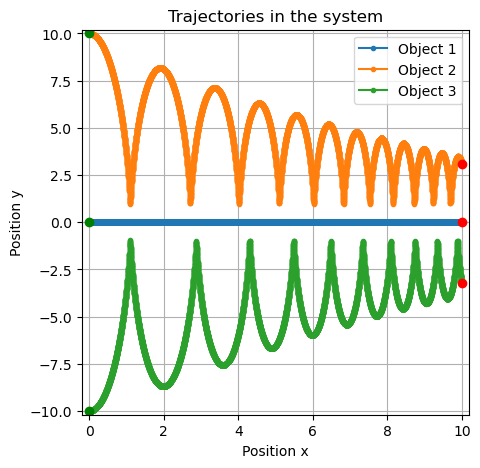

In [13]:
plt.figure(figsize=(5,5))
for i in range(N_objects):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Trajectories in the system')
plt.legend()
plt.xlim(-0.2, 10.2)
plt.ylim(-10.2, 10.2)
plt.grid()
plt.show()

Looking at the trajectories here, we can clearly see the objects bouncing, as the gravity pulls the lighter objects back to the centre each time they move away, while also losing some energy each bounce, resulting in the decreasing amplitude.

On closer inspection, you can however also see that the bouncing objects 2 and 3 do not mirror each other perfectly. Object 3 (green, below object 1) reaches a slightly larger amplitude each bounce, so that it also comes back at a later time. Meanwhile, object 2 (orange, above object 1) reaches a slightly smaller amplitude, as it not quite reaches its initial distance from object 1 again. This desynchronizes the positions where the lighter objects collide with the larger one. Additionally, if we switch around the order of the objects, meaning number 2 is now below 1, the reverse happens, so the object above object 1 now gets a larger amplitude. This indicates the problem has to do with the order in which we calculate the velocities after a collision; the one we calculate first ends up with the smaller amplitude.

This then happens because after the first object collides, the heavier object gets a small velocity in the opposite direction, and the lighter object loses a small amount of momentum. So when the second object collides, in the next step of our loop, this extra momentum is transferred to it, giving it a slightly larger velocity which allows it to move away further and return for the next collision later. Meanwhile the first colliding object left with a slightly smaller velocity, so it moves away less far and returns sooner. The central heavy object remains in the middle as it passes on the momentum from the first collision in the second and only keeps a negligible amount itself. This shows that the simulation does not work perfectly for collisions that should be simultaneous.

We do also see that for even smaller masses of order 0.01 instead of 1 this effect becomes so small that it cannot be seen anymore, and both objects have the same amplitude as expected.

We can see this effect for $e=1$ as well; here objects 3 reaches a larger and object 2 a smaller amplitude than the initial distance of 10. However, when there is only one of them present, that one does exactly reach an amplitude of 10 each bounce, as we would expect. This happens because in the case of a single bouncing object, the heavy object is also slightly pulled towards it, and is slightly pushed away again in the collision, so that the lighter object gains more velocity (imagine two objects of the same mass, how they bounce off each other; as one's mass increases, its amplitude becomes smaller until it is not visible anymore) than in the case of two bouncing objects, where the gravity of both keeps the heavy central object exactly in the middle and the first colliding lighter object does not get this extra push.

Additionally, if you set $e=0.9$ or smaller, you see the objects start to move within each other's radius. This happens because the force is large enough to overcome the reversed velocities, so that the  objects don't actually start to move apart. It can be fixed by using a smaller timestep though.

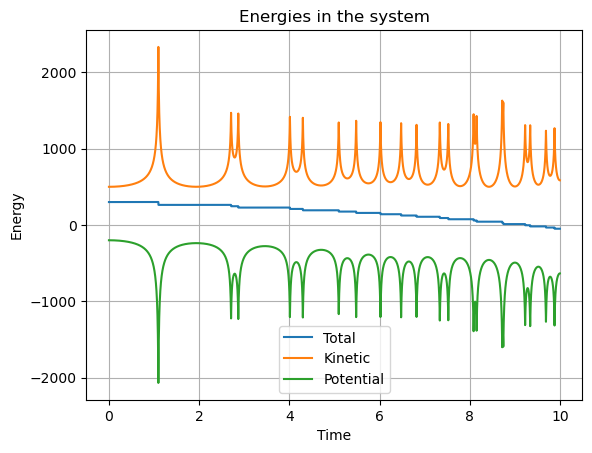

In [14]:
times = np.arange(N_steps) * dt
# Get the kinetic energies from velocities
kinetic_per_particle = 0.5 * masses * np.sum(velocities**2, axis=2)
kinetic_total = np.sum(kinetic_per_particle, axis=1)

# Get the potential energies from positions
potential_total = np.zeros(shape=[N_steps])
for j in range(N_objects-1):  # don't need to consider the last object, is cancelled in next loop
    r_j = positions[:,j,:]
    for k in range(j+1, N_objects):  # start from the object after j
        r_k = positions[:,k,:]
        distance = np.linalg.norm(r_j - r_k, axis=1)  # distance between j and k at all timesteps
        
        potential_jk = -G * masses[j] * masses[k] / distance
        potential_total += potential_jk

energy = kinetic_total + potential_total

# Plot the different energies over time
plt.figure()
plt.plot(times, energy, label="Total")
plt.plot(times, kinetic_total, label="Kinetic")
plt.plot(times, potential_total, label="Potential")
plt.title("Energies in the system")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.grid()
plt.show()

In the energy plot, we can see each collision as a peak in kinetic and potential energy, and a small decrease in total energy. This also shows the desynchronisation of the collisions quite clearly.